In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy
import statsmodels

In [2]:
metrics = ["degree_centralities", "clustering_coefs", "node_bcs"]

Degree:

In [19]:
t = pd.read_csv("metrics_data/data/drosophila_m/degree_centralities.csv")
t = t[t.columns[1:]].fillna(0)
p = pd.read_csv("metrics_data/data/drosophila_m/protein_degree_centralities.csv")
p = p[p.columns[1:]].fillna(0)

common_cols = list(set(t.columns)&set(p.columns))

t = t[common_cols]
p = p[common_cols]

t["file_name"] = t["file_name"].str.split("_",expand=True)[3].str[:-1].astype(int)
p["file_name"] = p["file_name"].str[-9:-7].astype(int)

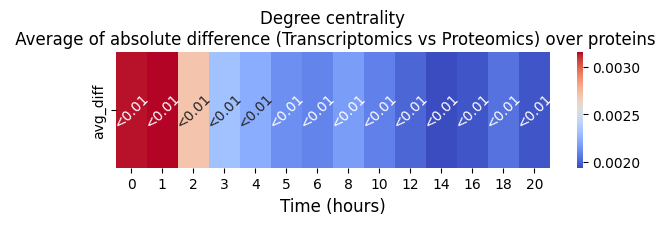

In [4]:
plt.figure(figsize=(7,1.5))
t_aligned = t.set_index("file_name")
p_aligned = p.set_index("file_name")
t_aligned, p_aligned = t_aligned.align(p_aligned, join="inner", axis=0)

aux1 = t_aligned.groupby("file_name").mean()
aux2 = p_aligned.groupby("file_name").mean()

diffs = abs(aux1-aux2)
diffs_avg = diffs.mean(axis=1).to_frame("avg_diff").T
labels = diffs_avg.copy()

labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs_avg, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Degree centrality\n Average of absolute difference (Transcriptomics vs Proteomics) over proteins")
plt.xlabel("Time (hours)", fontsize=12)
plt.savefig("figures/embryo_local_heatmap_degree.pdf", bbox_inches='tight')

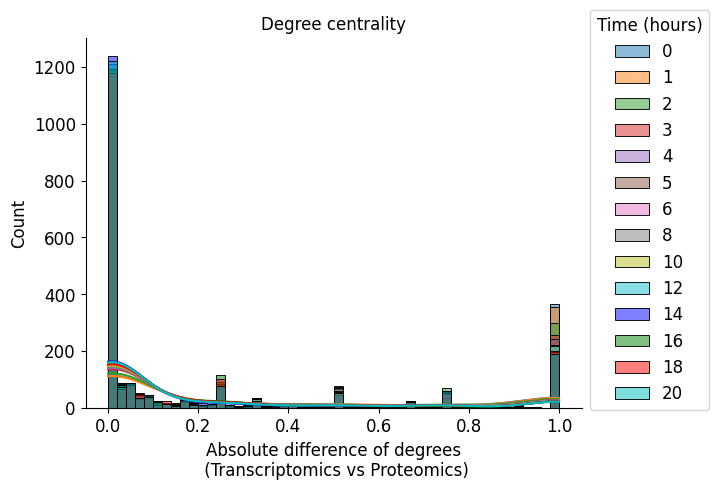

In [20]:
matplotlib.rcParams.update({'font.size': 12})
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:grey", "tab:olive", "tab:cyan", "b", "g", "r", "c"]
j=0
for i,row in diffs.iterrows():
    sns.histplot(row, kde=True, label=i, color=colors[j], bins=50)
    j+=1
plt.legend(title="Time (hours)", loc=0, bbox_to_anchor=(1,1.1))
sns.despine()
plt.xlabel("Absolute difference of degrees\n (Transcriptomics vs Proteomics)")
plt.title("Degree centrality", fontsize=12)
plt.savefig("figures/embryo_local_hist_degree.pdf", bbox_inches='tight')

Clustering:

In [5]:
t = pd.read_csv("metrics_data/data/drosophila_m/clustering_coefs.csv")
t = t[t.columns[1:]].fillna(0)
p = pd.read_csv("metrics_data/data/drosophila_m/protein_clustering_coefs.csv")
p = p[p.columns[1:]].fillna(0)

common_cols = list(set(t.columns)&set(p.columns))

t = t[common_cols]
p = p[common_cols]

t["file_name"] = t["file_name"].str.split("_",expand=True)[3].str[:-1].astype(int)
p["file_name"] = p["file_name"].str[-9:-7].astype(int)

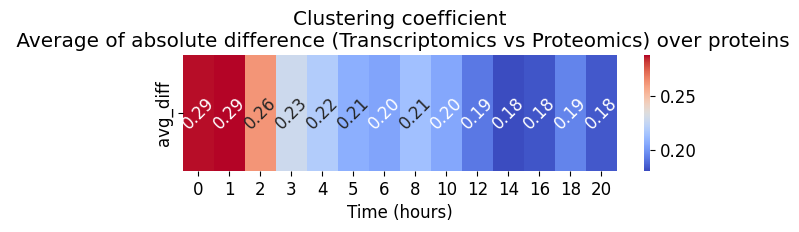

In [6]:
plt.figure(figsize=(7,1.5))
t_aligned = t.set_index("file_name")
p_aligned = p.set_index("file_name")
t_aligned, p_aligned = t_aligned.align(p_aligned, join="inner", axis=0)

aux1 = t_aligned.groupby("file_name").mean()
aux2 = p_aligned.groupby("file_name").mean()

diffs = abs(aux1-aux2)
diffs_avg = diffs.mean(axis=1).to_frame("avg_diff").T
labels = diffs_avg.copy()

labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs_avg, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Clustering coefficient\n Average of absolute difference (Transcriptomics vs Proteomics) over proteins")
plt.xlabel("Time (hours)", fontsize=12)
plt.savefig("figures/embryo_local_heatmap_clustering.pdf", bbox_inches='tight')

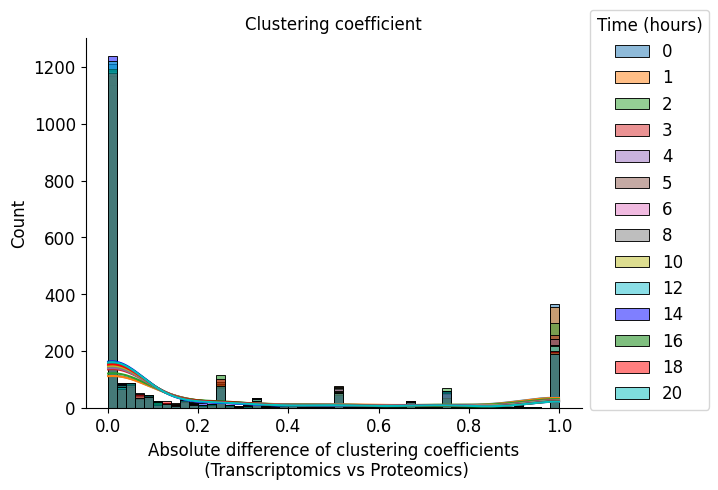

In [7]:
matplotlib.rcParams.update({'font.size': 12})
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:grey", "tab:olive", "tab:cyan", "b", "g", "r", "c"]
j=0
for i,row in diffs.iterrows():
    sns.histplot(row, kde=True, label=i, color=colors[j], bins=50)
    j+=1
plt.legend(title="Time (hours)", loc=0, bbox_to_anchor=(1,1.1))
sns.despine()
plt.xlabel("Absolute difference of clustering coefficients\n (Transcriptomics vs Proteomics)")
plt.title("Clustering coefficient", fontsize=12)
plt.savefig("figures/embryo_local_hist_clustering.pdf", bbox_inches='tight')

Node bcs:

In [21]:
t = pd.read_csv("metrics_data/data/drosophila_m/node_bcs.csv")
t = t[t.columns[1:]].fillna(0)
p = pd.read_csv("metrics_data/data/drosophila_m/protein_node_bcs.csv")
p = p[p.columns[1:]].fillna(0)

common_cols = list(set(t.columns)&set(p.columns))

t = t[common_cols]
p = p[common_cols]

t["file_name"] = t["file_name"].str.split("_",expand=True)[3].str[:-1].astype(int)
p["file_name"] = p["file_name"].str[-9:-7].astype(int)

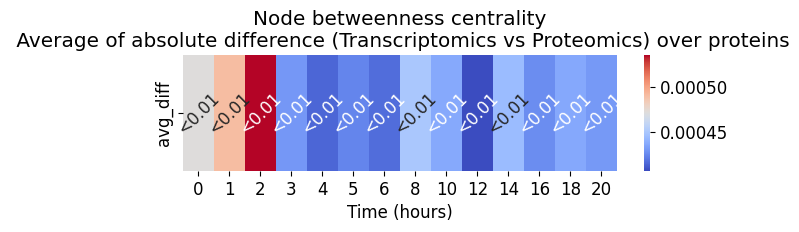

In [23]:
plt.figure(figsize=(7,1.5))
t_aligned = t.set_index("file_name")
p_aligned = p.set_index("file_name")
t_aligned, p_aligned = t_aligned.align(p_aligned, join="inner", axis=0)

aux1 = t_aligned.groupby("file_name").mean()
aux2 = p_aligned.groupby("file_name").mean()

diffs = abs(aux1-aux2)
diffs_avg = diffs.mean(axis=1).to_frame("avg_diff").T
labels = diffs_avg.copy()

labels = labels.applymap(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
sns.heatmap(diffs_avg, annot=labels, cmap="coolwarm", annot_kws={"rotation": 45}, fmt="")
plt.title("Node betweenness centrality\n Average of absolute difference (Transcriptomics vs Proteomics) over proteins")
plt.xlabel("Time (hours)", fontsize=12)
plt.savefig("figures/embryo_local_heatmap_node_bcs.pdf", bbox_inches='tight')

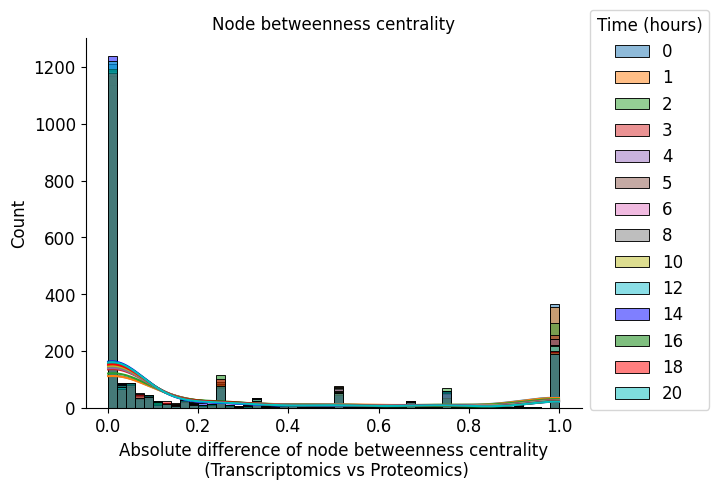

In [22]:
matplotlib.rcParams.update({'font.size': 12})
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:grey", "tab:olive", "tab:cyan", "b", "g", "r", "c"]
j=0
for i,row in diffs.iterrows():
    sns.histplot(row, kde=True, label=i, color=colors[j], bins=50)
    j+=1
plt.legend(title="Time (hours)", loc=0, bbox_to_anchor=(1,1.1))
sns.despine()
plt.xlabel("Absolute difference of node betweenness centrality\n (Transcriptomics vs Proteomics)")
plt.title("Node betweenness centrality", fontsize=12)
plt.savefig("figures/embryo_local_hist_node_bcs.pdf", bbox_inches='tight')

## Trend:

In [31]:
df = pd.read_csv("local_tests/embryo_degree_centralities_tendency.csv.csv")
df["transcriptomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["transcriptomic_pvalue"])[1]
df["proteomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["proteomic_pvalue"])[1]
df["transcriptomic_plot"] = np.sign(df["transcriptomic_coef"])*np.log10(df["transcriptomic_pvalue_fdr"])*(-1)
df["proteomic_plot"] = np.sign(df["proteomic_coef"])*np.log10(df["proteomic_pvalue_fdr"])*(-1)

In [32]:
np.log10(0.05)

-1.3010299956639813

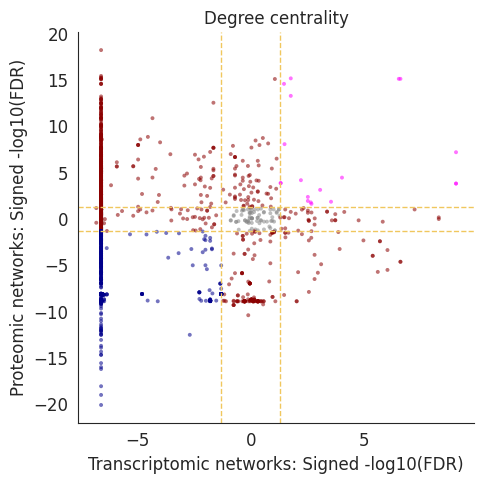

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sig_thresh = -np.log10(0.05)  
x_thresh = -np.log10(0.05)

matplotlib.rcParams.update({'font.size': 12})
def classify(row):
    x, y = row["transcriptomic_plot"], row["proteomic_plot"]

    # both significant
    if (abs(x) > x_thresh and abs(y) > sig_thresh) and ((x<0 and y<0)):
        return "both_neg"
    
    elif (abs(x) > x_thresh and abs(y) > sig_thresh) and ((x>0 and y>0)):
        return "both_pos"

    elif abs(x) > x_thresh:
        return "t"

    elif abs(y) > sig_thresh:
        return "p"

    else:
        return "none"

df["group"] = df.apply(classify, axis=1)

palette = {
    "both_neg": "darkblue", 
    "both_pos":"magenta",
    "t": "darkred", 
    "p": "darkred",
    "none": "#888888"   
}


sns.set_style("white")
fig, ax = plt.subplots(figsize=(5, 5))

for grp in ["none", "p", "t", "both_neg", "both_pos"]:
    d = df[df["group"] == grp]

    ax.scatter(
        d["transcriptomic_plot"],
        d["proteomic_plot"],
        s=8,
        c=palette[grp],
        alpha=0.55,
        edgecolors="none",
        label=grp
    )

for v in [-x_thresh, x_thresh]:
    ax.axvline(v,
               color="#f0c75e",
               linestyle="--",
               lw=1)

for h in [-sig_thresh, sig_thresh]:
    ax.axhline(h,
               color="#f0c75e",
               linestyle="--",
               lw=1)

ax.set_xlabel(
    "Transcriptomic networks: Signed -log10(FDR)"
)

ax.set_ylabel(
    "Proteomic networks: Signed -log10(FDR)"
)



sns.despine()
plt.tight_layout()
plt.title("Degree centrality", fontsize=12)
plt.savefig("figures/embryo_local_degree_tendency_scatter.pdf", bbox_inches='tight')

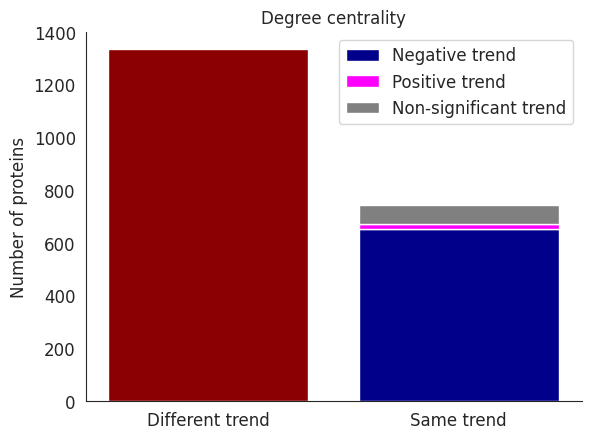

In [34]:
df = pd.DataFrame({
    'single': [1334],
    'Negative trend': [654],
    'Positive trend': [19],
    'Non-significant trend': [72]
})

fig, ax = plt.subplots()

# Single bar
ax.bar('Different trend', df.loc[0, 'single'], color="darkred")

# Stacked bar
bottom = 0
colors = {'Negative trend':"darkblue", 'Positive trend':"magenta", 'Non-significant trend':"grey"}
for col in colors:
    ax.bar('Same trend', df.loc[0, col], bottom=bottom, label=col, color=colors[col])
    bottom += df.loc[0, col]

ax.set_ylabel('Number of proteins')
ax.legend()
sns.despine()
plt.title("Degree centrality", fontsize=12)
plt.savefig("figures/embryo_local_degree_tendency_bar.pdf", bbox_inches='tight')

In [52]:
len(df[(df["transcriptomic_plot"]<np.log10(0.05))&(df["proteomic_plot"]<np.log10(0.05))])
## sign-sign, negative, negative

654

In [54]:
len(df[(df["transcriptomic_plot"]>-np.log10(0.05))&(df["proteomic_plot"]>-np.log10(0.05))])
## sign-sign, positive, positive

19

In [55]:
len(df[(df["transcriptomic_pvalue_fdr"]>=0.05)&(df["proteomic_pvalue_fdr"]>=0.05)])
## nonsign-nonsign

72

In [56]:
len(df)

2079

In [57]:
2079-72-19-654
## different trend

1334

In [58]:
72+19+654
## same trend

745

In [59]:
745/2079

0.35834535834535836

In [9]:
(np.sign(df["transcriptomic_coef"])==np.sign(df["proteomic_coef"])).sum()

1073

In [34]:
different_trend = df[df["group"].isin(["t","p"])]
different_trend

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot,group
1,7227.FBpp0306651,-4.746414e-06,1.729346e-07,0.000027,1.906112e-01,2.370013e-07,2.302619e-01,-6.625249,0.637778,t
2,7227.FBpp0073631,-2.712237e-06,1.729346e-07,0.000035,1.193869e-07,2.370013e-07,3.476266e-07,-6.625249,6.458887,t
4,7227.FBpp0080103,-5.424473e-06,1.729346e-07,0.000023,3.436524e-01,2.370013e-07,3.904117e-01,-6.625249,0.408477,t
6,7227.FBpp0080649,-4.843363e-06,1.572679e-01,-0.000149,1.377060e-10,1.747515e-01,1.331441e-09,-0.757579,-8.875678,p
7,7227.FBpp0078568,-4.068355e-06,1.729346e-07,0.000120,2.068503e-05,2.370013e-07,4.594464e-05,-6.625249,4.337765,t
...,...,...,...,...,...,...,...,...,...,...
2072,7227.FBpp0072788,-6.780592e-07,1.729346e-07,0.000030,3.167262e-08,2.370013e-07,9.976877e-08,-6.625249,7.001005,t
2073,7227.FBpp0289702,1.828390e-05,1.186245e-03,-0.000027,2.111377e-01,1.498301e-03,2.540251e-01,2.824401,-0.595123,t
2076,7227.FBpp0082995,-3.390296e-06,1.729346e-07,-0.000005,2.378123e-01,2.370013e-07,2.826825e-01,-6.625249,-0.548701,t
2077,7227.FBpp0304751,-5.424473e-06,1.729346e-07,0.000055,3.278608e-05,2.370013e-07,7.027037e-05,-6.625249,4.153228,t


In [35]:
(np.sign(different_trend["transcriptomic_coef"])==np.sign(different_trend["proteomic_coef"])).sum()

361

In [36]:
len(different_trend[different_trend["transcriptomic_pvalue_fdr"]<0.05])

1140

In [37]:
len(different_trend[different_trend["proteomic_pvalue_fdr"]<0.05])

782

In [41]:
len(different_trend[(different_trend["transcriptomic_pvalue_fdr"]<0.05)&(different_trend["transcriptomic_coef"]<0)])

1079

In [43]:
len(different_trend[(different_trend["proteomic_pvalue_fdr"]<0.05)&(different_trend["proteomic_coef"]<0)]), len(different_trend[(different_trend["proteomic_pvalue_fdr"]<0.05)&(different_trend["proteomic_coef"]>0)])

(161, 621)

More sign. in transcriptomics than proteomics. Direction is often different.

Global average shows same trend (sign. negative for both). Locally: transcriptomic network --> almost only degree decrease; proteomic network --> roughly balanced, but more decrease than increase, which could explain the overall decrease.

In [35]:
df = pd.read_csv("local_tests/embryo_clustering_coefs_tendency.csv.csv")
df = df.fillna(1)
df["transcriptomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["transcriptomic_pvalue"])[1]
df["proteomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["proteomic_pvalue"])[1]
df["transcriptomic_plot"] = np.sign(df["transcriptomic_coef"])*np.log10(df["transcriptomic_pvalue_fdr"])*(-1)
df["proteomic_plot"] = np.sign(df["proteomic_coef"])*np.log10(df["proteomic_pvalue_fdr"])*(-1)

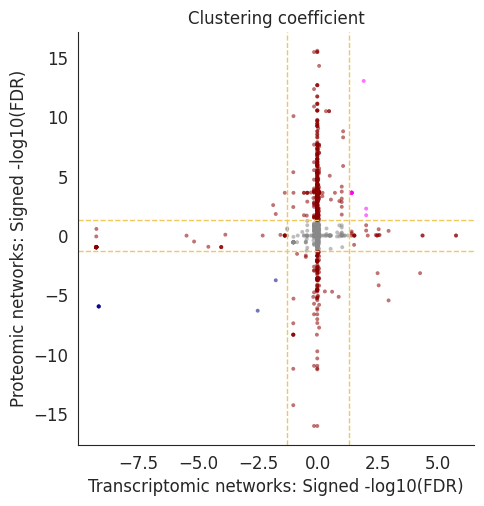

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sig_thresh = -np.log10(0.05)  
x_thresh = -np.log10(0.05)

matplotlib.rcParams.update({'font.size': 12})
def classify(row):
    x, y = row["transcriptomic_plot"], row["proteomic_plot"]

    # both significant
    if (abs(x) > x_thresh and abs(y) > sig_thresh) and ((x<0 and y<0)):
        return "both_neg"
    
    elif (abs(x) > x_thresh and abs(y) > sig_thresh) and ((x>0 and y>0)):
        return "both_pos"

    elif abs(x) > x_thresh:
        return "t"

    elif abs(y) > sig_thresh:
        return "p"

    else:
        return "none"

df["group"] = df.apply(classify, axis=1)

palette = {
    "both_neg": "darkblue", 
    "both_pos":"magenta",
    "t": "darkred", 
    "p": "darkred",
    "none": "#888888"   
}


sns.set_style("white")
fig, ax = plt.subplots(figsize=(5, 5))

for grp in ["none", "p", "t", "both_neg", "both_pos"]:
    d = df[df["group"] == grp]

    ax.scatter(
        d["transcriptomic_plot"],
        d["proteomic_plot"],
        s=8,
        c=palette[grp],
        alpha=0.55,
        edgecolors="none",
        label=grp
    )

for v in [-x_thresh, x_thresh]:
    ax.axvline(v,
               color="#f0c75e",
               linestyle="--",
               lw=1)

for h in [-sig_thresh, sig_thresh]:
    ax.axhline(h,
               color="#f0c75e",
               linestyle="--",
               lw=1)

ax.set_xlabel(
    "Transcriptomic networks: Signed -log10(FDR)"
)

ax.set_ylabel(
    "Proteomic networks: Signed -log10(FDR)"
)


sns.despine()
plt.tight_layout()
plt.title("Clustering coefficient", fontsize=12)
plt.savefig("figures/embryo_local_clustering_tendency_scatter.pdf", bbox_inches='tight')

In [91]:
print(len(df[(df["transcriptomic_plot"]<np.log10(0.05))&(df["proteomic_plot"]<np.log10(0.05))]))
## sign-sign, negative, negative

print(len(df[(df["transcriptomic_plot"]>-np.log10(0.05))&(df["proteomic_plot"]>-np.log10(0.05))]))
## sign-sign, positive, positive

print(len(df[(df["transcriptomic_pvalue_fdr"]>=0.05)&(df["proteomic_pvalue_fdr"]>=0.05)]))
## nonsign-nonsign

print(len(df))

6
13
1080
2079


In [92]:
2079-6-13-1080
## different trend

980

In [93]:
6+13+1080
## same trend

1099

In [94]:
1099/2079

0.5286195286195287

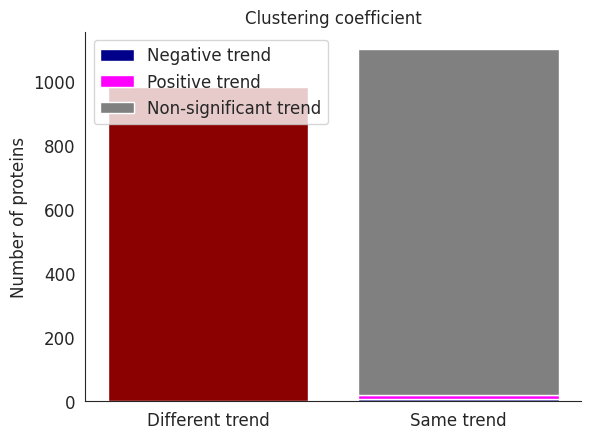

In [37]:
df = pd.DataFrame({
    'single': [980],
    'Negative trend': [6],
    'Positive trend': [13],
    'Non-significant trend': [1080]
})

fig, ax = plt.subplots()

# Single bar
ax.bar('Different trend', df.loc[0, 'single'], color="darkred")

# Stacked bar
bottom = 0
colors = {'Negative trend':"darkblue", 'Positive trend':"magenta", 'Non-significant trend':"grey"}
for col in colors:
    ax.bar('Same trend', df.loc[0, col], bottom=bottom, label=col, color=colors[col])
    bottom += df.loc[0, col]

ax.set_ylabel('Number of proteins')
ax.legend(loc=2)
sns.despine()
plt.title("Clustering coefficient", fontsize=12)
plt.savefig("figures/embryo_local_clustering_tendency_bar.pdf", bbox_inches='tight')

In [15]:
different_trend = df[df["group"].isin(["t","p"])]
different_trend

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot,group
2,7227.FBpp0073631,-6.071532e-18,9.749153e-02,2.373558e-02,2.878727e-05,6.714237e-01,2.145116e-04,-0.173003,3.668549,p
5,7227.FBpp0073988,-1.734723e-18,7.171123e-01,2.298509e-17,8.337488e-05,9.157718e-01,2.504861e-04,-0.038213,3.601216,p
6,7227.FBpp0080649,-1.734723e-18,7.171123e-01,-3.371783e-02,5.601545e-07,9.157718e-01,7.370641e-06,-0.038213,-5.132495,p
7,7227.FBpp0078568,-1.734723e-18,7.171123e-01,3.704525e-02,1.577427e-06,9.157718e-01,1.850473e-05,-0.038213,4.732717,p
9,7227.FBpp0081845,-1.188666e-03,7.161862e-12,-8.286839e-05,5.013529e-02,5.726735e-10,1.041271e-01,-9.242093,-0.982436,t
...,...,...,...,...,...,...,...,...,...,...
2066,7227.FBpp0289903,-1.734723e-18,7.171123e-01,2.298509e-17,8.337488e-05,9.157718e-01,2.504861e-04,-0.038213,3.601216,p
2069,7227.FBpp0089163,-5.204170e-18,3.676317e-01,-1.651033e-03,2.285918e-05,9.157718e-01,1.820852e-04,-0.038213,-3.739725,p
2070,7227.FBpp0308633,-2.083837e-04,1.524826e-01,-2.316728e-02,5.431733e-14,9.157718e-01,6.273651e-12,-0.038213,-11.202480,p
2073,7227.FBpp0289702,3.007000e-03,1.057411e-04,1.774623e-03,6.311093e-01,3.997013e-03,9.061300e-01,2.398264,0.042809,t


In [16]:
(np.sign(different_trend["transcriptomic_coef"])==np.sign(different_trend["proteomic_coef"])).sum()

199

In [18]:
len(different_trend[different_trend["transcriptomic_pvalue_fdr"]<0.05])

71

In [19]:
len(different_trend[different_trend["proteomic_pvalue_fdr"]<0.05])

916

Much more sign. in proteomics than transcriptomics. Direction is often different.

Global avg has the same trend, non-significantly changes for both. Transcriptomic does not change here locally as well, proteomic sign. changes do not seem to have a large influence on global characteristic (overall more non-sign. change than sign. locally for proteomic too).

In [38]:
df = pd.read_csv("local_tests/embryo_node_bcs_tendency.csv.csv")
df = df.fillna(1)
df["transcriptomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["transcriptomic_pvalue"])[1]
df["proteomic_pvalue_fdr"] = statsmodels.stats.multitest.fdrcorrection(df["proteomic_pvalue"])[1]
df["transcriptomic_plot"] = np.sign(df["transcriptomic_coef"])*np.log10(df["transcriptomic_pvalue_fdr"])*(-1)
df["proteomic_plot"] = np.sign(df["proteomic_coef"])*np.log10(df["proteomic_pvalue_fdr"])*(-1)

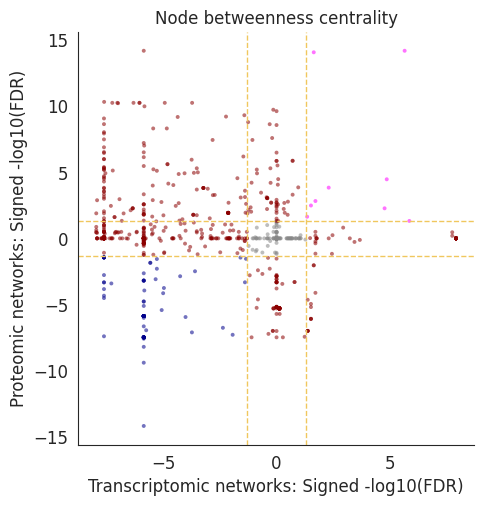

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sig_thresh = -np.log10(0.05)  
x_thresh = -np.log10(0.05)

matplotlib.rcParams.update({'font.size': 12})
def classify(row):
    x, y = row["transcriptomic_plot"], row["proteomic_plot"]

    # both significant
    if (abs(x) > x_thresh and abs(y) > sig_thresh) and ((x<0 and y<0)):
        return "both_neg"
    
    elif (abs(x) > x_thresh and abs(y) > sig_thresh) and ((x>0 and y>0)):
        return "both_pos"

    elif abs(x) > x_thresh:
        return "t"

    elif abs(y) > sig_thresh:
        return "p"

    else:
        return "none"

df["group"] = df.apply(classify, axis=1)

palette = {
    "both_neg": "darkblue", 
    "both_pos":"magenta",
    "t": "darkred", 
    "p": "darkred",
    "none": "#888888"   
}


sns.set_style("white")
fig, ax = plt.subplots(figsize=(5, 5))

for grp in ["none", "p", "t", "both_neg", "both_pos"]:
    d = df[df["group"] == grp]

    ax.scatter(
        d["transcriptomic_plot"],
        d["proteomic_plot"],
        s=8,
        c=palette[grp],
        alpha=0.55,
        edgecolors="none",
        label=grp
    )

for v in [-x_thresh, x_thresh]:
    ax.axvline(v,
               color="#f0c75e",
               linestyle="--",
               lw=1)

for h in [-sig_thresh, sig_thresh]:
    ax.axhline(h,
               color="#f0c75e",
               linestyle="--",
               lw=1)

ax.set_xlabel(
    "Transcriptomic networks: Signed -log10(FDR)"
)

ax.set_ylabel(
    "Proteomic networks: Signed -log10(FDR)"
)


sns.despine()
plt.tight_layout()
plt.title("Node betweenness centrality", fontsize=12)
plt.savefig("figures/embryo_local_node_bcs_tendency_scatter.pdf", bbox_inches='tight')

In [100]:
print(len(df[(df["transcriptomic_plot"]<np.log10(0.05))&(df["proteomic_plot"]<np.log10(0.05))]))
## sign-sign, negative, negative

print(len(df[(df["transcriptomic_plot"]>-np.log10(0.05))&(df["proteomic_plot"]>-np.log10(0.05))]))
## sign-sign, positive, positive

print(len(df[(df["transcriptomic_pvalue_fdr"]>=0.05)&(df["proteomic_pvalue_fdr"]>=0.05)]))
## nonsign-nonsign

print(len(df))

84
9
1447
2079


In [101]:
2079-84-9-1447
## different trend

539

In [102]:
84+9+1447
## same trend

1540

In [103]:
1540/2079

0.7407407407407407

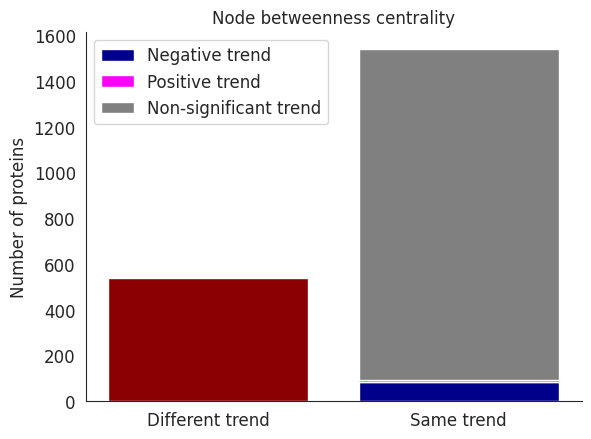

In [40]:
df = pd.DataFrame({
    'single': [539],
    'Negative trend': [84],
    'Positive trend': [9],
    'Non-significant trend': [1447]
})

fig, ax = plt.subplots()

# Single bar
ax.bar('Different trend', df.loc[0, 'single'], color="darkred")

# Stacked bar
bottom = 0
colors = {'Negative trend':"darkblue", 'Positive trend':"magenta", 'Non-significant trend':"grey"}
for col in colors:
    ax.bar('Same trend', df.loc[0, col], bottom=bottom, label=col, color=colors[col])
    bottom += df.loc[0, col]

ax.set_ylabel('Number of proteins')
ax.legend(loc=2)
sns.despine()
plt.title("Node betweenness centrality", fontsize=12)
plt.savefig("figures/embryo_local_node_bcs_tendency_bar.pdf", bbox_inches='tight')

In [28]:
different_trend = df[df["group"].isin(["t","p"])]
different_trend

,node,transcriptomic_coef,transcriptomic_pvalue,proteomic_coef,proteomic_pvalue,transcriptomic_pvalue_fdr,proteomic_pvalue_fdr,transcriptomic_plot,proteomic_plot,group
0,7227.FBpp0303780,2.348603e-10,2.321202e-01,-4.685097e-09,3.838235e-07,7.552081e-01,5.050438e-06,0.121933,-5.296671,p
1,7227.FBpp0306651,-7.106410e-06,2.621746e-08,9.284751e-05,1.189251e-01,3.096938e-07,5.097839e-01,-6.509067,0.292614,t
2,7227.FBpp0073631,-4.231739e-07,2.535370e-04,0.000000e+00,1.000000e+00,1.295094e-03,1.000000e+00,-2.887699,-0.000000,t
8,7227.FBpp0305562,2.348603e-10,2.321202e-01,-4.685097e-09,3.838235e-07,7.552081e-01,5.050438e-06,0.121933,-5.296671,p
9,7227.FBpp0081845,2.923138e-08,1.997490e-10,1.720827e-10,9.513166e-01,1.153550e-08,1.000000e+00,7.937963,-0.000000,t
...,...,...,...,...,...,...,...,...,...,...
2069,7227.FBpp0089163,-4.271569e-07,1.577865e-09,1.736257e-06,1.872312e-01,2.327995e-08,7.632426e-01,-7.633018,0.117337,t
2070,7227.FBpp0308633,-8.158514e-06,2.140636e-07,2.197080e-04,7.011285e-13,1.435607e-06,1.041176e-10,-5.842964,9.982476,t
2071,7227.FBpp0311465,-2.579122e-06,1.626143e-09,7.746864e-06,6.945494e-02,2.327995e-08,3.215965e-01,-7.633018,0.492689,t
2073,7227.FBpp0289702,-1.204810e-06,2.409164e-05,-5.947942e-06,2.364826e-02,1.350041e-04,1.226053e-01,-3.869653,-0.911491,t


In [29]:
(np.sign(different_trend["transcriptomic_coef"])==np.sign(different_trend["proteomic_coef"])).sum()

148

In [30]:
len(different_trend[different_trend["transcriptomic_pvalue_fdr"]<0.05])

409

In [31]:
len(different_trend[different_trend["proteomic_pvalue_fdr"]<0.05])

272

More sign. in transcriptomics than in proteomics. Direction is often different.

Global avg node bc had different trend (non-sign prot., sign. transc., different signs) --> since mostly the non-sign. changing nodes have the same trend locally, even though smaller portion of nodes' trend differ, possibly they influence the global characteristic, especially for the transcriptomic network, it has more sign. local changes too.

Overall: local characteristics give further insight into the network structure, it points to non-homogeneous age-related changes in the networks, which might bias the global charactristics. (e.g. node bc showed different global trend, but local structure reveals that there is a large similarity; degree showed same sign. decreasing trend, but local structure reveals that in the proteomic network many node's degree increases in contrast to the roughly homogeneous decrease in the transcriptomic network, which makes the comparison/similarity more nuanced).

## Interaction term:

In [23]:
df = pd.read_csv("local_tests/embryo_degree_centralities_interaction.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["interaction_pvalue"])[1]

In [24]:
df[df["fdr_pvalue"]<0.05]

,node,interaction_coef,interaction_pvalue,fdr_pvalue
0,7227.FBpp0303780,-0.000471,2.190920e-09,7.720210e-09
2,7227.FBpp0073631,0.000038,2.013543e-09,7.529057e-09
3,7227.FBpp0072560,-0.000006,3.379736e-10,1.645543e-09
6,7227.FBpp0080649,-0.000144,1.612312e-11,2.081986e-10
7,7227.FBpp0078568,0.000124,4.685579e-06,1.070475e-05
...,...,...,...,...
2071,7227.FBpp0311465,0.000041,2.036339e-02,3.015348e-02
2072,7227.FBpp0072788,0.000030,1.590707e-09,6.068037e-09
2074,7227.FBpp0310109,-0.000006,3.379736e-10,1.645543e-09
2075,7227.FBpp0304248,-0.000233,3.284391e-03,5.440835e-03


In [25]:
len(df)

2079

In [26]:
df = pd.read_csv("local_tests/embryo_clustering_coefs_interaction.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["interaction_pvalue"])[1]

In [27]:
df[df["fdr_pvalue"]<0.05]

,node,interaction_coef,interaction_pvalue,fdr_pvalue
0,7227.FBpp0303780,4.226551e-05,2.339548e-02,4.528789e-02
2,7227.FBpp0073631,2.373558e-02,1.304286e-05,7.408772e-05
5,7227.FBpp0073988,-6.570265e-17,2.120997e-02,4.260437e-02
6,7227.FBpp0080649,-3.371783e-02,1.169735e-07,9.845663e-07
7,7227.FBpp0078568,3.704525e-02,4.143140e-07,3.166760e-06
...,...,...,...,...
2066,7227.FBpp0289903,-6.570265e-17,2.120997e-02,4.260437e-02
2067,7227.FBpp0309532,-5.903051e-03,1.009486e-07,8.566206e-07
2069,7227.FBpp0089163,-1.651033e-03,9.970929e-06,5.822911e-05
2070,7227.FBpp0308633,-2.295890e-02,5.894155e-17,6.449447e-15


In [28]:
len(df)

2079

In [29]:
df = pd.read_csv("local_tests/embryo_node_bcs_interaction.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["interaction_pvalue"])[1]

In [30]:
df[df["fdr_pvalue"]<0.05]

,node,interaction_coef,interaction_pvalue,fdr_pvalue
0,7227.FBpp0303780,-4.919957e-09,4.197595e-08,4.385327e-07
2,7227.FBpp0073631,4.231739e-07,1.571412e-04,9.202717e-04
8,7227.FBpp0305562,-4.919957e-09,4.197595e-08,4.385327e-07
9,7227.FBpp0081845,-2.905930e-08,9.946404e-09,1.466566e-07
11,7227.FBpp0309997,-2.961856e-06,6.050493e-05,3.811811e-04
...,...,...,...,...
2061,7227.FBpp0100176,-5.241062e-08,9.659000e-05,5.976506e-04
2067,7227.FBpp0309532,4.080327e-06,2.338506e-06,1.794006e-05
2068,7227.FBpp0311089,1.180282e-05,1.158391e-10,3.168810e-09
2070,7227.FBpp0308633,2.278665e-04,2.498695e-16,4.328988e-14


In [31]:
len(df)

2079

In [41]:
res = pd.DataFrame({"metric":["degree_centralities", "degree_centralities", "clustering_coefs", "clustering_coefs", "node_bcs", "node_bcs"], 
                    "num_sign":[1481, 2079-1481,1086, 2079-1086,468, 2079-468],
                    "sign":[True,False,True,False,True,False]})
res

,metric,num_sign,sign
0,degree_centralities,1481,True
1,degree_centralities,598,False
2,clustering_coefs,1086,True
3,clustering_coefs,993,False
4,node_bcs,468,True
5,node_bcs,1611,False


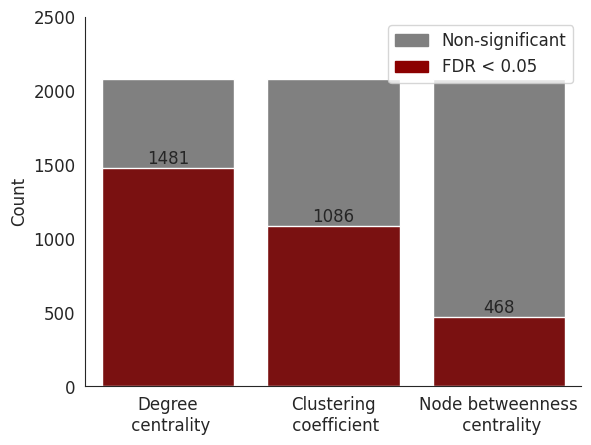

In [43]:
import matplotlib.patches as mpatches

matplotlib.rcParams.update({'font.size': 12})

total = res.groupby('metric')['num_sign'].sum().reset_index()
bar1 = sns.barplot(x="metric",  y="num_sign", data=total, color='grey')
bar2 = sns.barplot(x="metric",  y="num_sign", data=res[res["sign"]==True], color='darkred')
bar2.bar_label(bar2.containers[1], fontsize=12);

top_bar = mpatches.Patch(color='grey', label='Non-significant')
bottom_bar = mpatches.Patch(color='darkred', label='FDR < 0.05')
plt.legend(handles=[top_bar, bottom_bar], loc=1)

sns.despine()
plt.ylim(0,2500)
plt.ylabel("Count")
plt.xlabel("")
plt.xticks([0,1,2], ["Degree\n centrality", "Clustering\n coefficient", "Node betweenness\n centrality"])
plt.savefig("figures/embryo_local_interaction.pdf", bbox_inches='tight')

## Randomized test:

In [35]:
df = pd.read_csv("local_tests/embryo_degree_centralities_randomized.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["p_value"])[1]

In [36]:
len(df[df["fdr_pvalue"]<0.05]), len(df[df["p_value"]<0.01]), len(df)

(1, 17, 2079)

In [37]:
(1/2079)*100

0.0481000481000481

In [38]:
df = pd.read_csv("local_tests/embryo_clustering_coefs_randomized.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["p_value"])[1]

In [39]:
len(df[df["fdr_pvalue"]<0.05]), len(df[df["p_value"]<0.01]), len(df)

(506, 495, 2079)

In [41]:
(506/2079)*100

24.33862433862434

In [42]:
df = pd.read_csv("local_tests/embryo_node_bcs_randomized.csv.csv")
df = df.fillna(1)
df["fdr_pvalue"] = statsmodels.stats.multitest.fdrcorrection(df["p_value"])[1]

In [43]:
len(df[df["fdr_pvalue"]<0.05]), len(df[df["p_value"]<0.01]), len(df)

(1343, 1336, 2079)

In [44]:
(1343/2079)*100

64.5983645983646

In [44]:
res = pd.DataFrame({"metric":["degree_centralities", "degree_centralities", "clustering_coefs", "clustering_coefs", "node_bcs", "node_bcs"], 
                    "num_sign":[1, 2079-1,506, 2079-506,1343, 2079-1343],
                    "sign":[True,False,True,False,True,False]})
res

,metric,num_sign,sign
0,degree_centralities,1,True
1,degree_centralities,2078,False
2,clustering_coefs,506,True
3,clustering_coefs,1573,False
4,node_bcs,1343,True
5,node_bcs,736,False


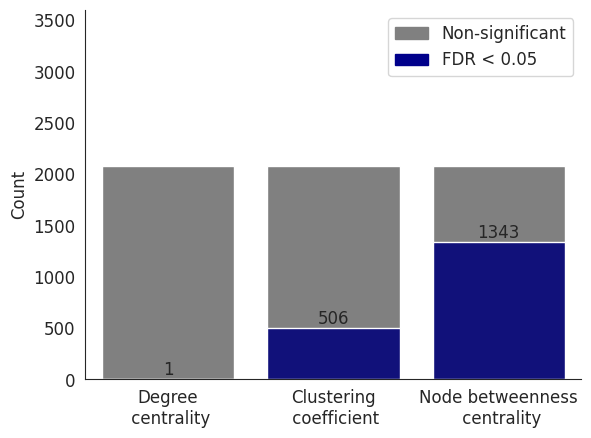

In [45]:
import matplotlib.patches as mpatches

matplotlib.rcParams.update({'font.size': 12})

total = res.groupby('metric')['num_sign'].sum().reset_index()
bar1 = sns.barplot(x="metric",  y="num_sign", data=total, color='grey')
bar2 = sns.barplot(x="metric",  y="num_sign", data=res[res["sign"]==True], color='darkblue')
bar2.bar_label(bar2.containers[1], fontsize=12);

top_bar = mpatches.Patch(color='grey', label='Non-significant')
bottom_bar = mpatches.Patch(color='darkblue', label='FDR < 0.05')
plt.legend(handles=[top_bar, bottom_bar], loc=1)

sns.despine()
plt.ylim(0,3600)
plt.ylabel("Count")
plt.xlabel("")
plt.xticks([0,1,2], ["Degree\n centrality", "Clustering\n coefficient", "Node betweenness\n centrality"])
plt.savefig("figures/embryo_local_randomized.pdf", bbox_inches='tight')